#### [ 수박, 키위, 딸기, 배 학습-> 제대로 분리 모델 만들기 ] <hr>

In [1]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")

import importlib
import cv_utils

importlib.reload(cv_utils)

from sklearn.model_selection import train_test_split #학습용| 테스트용 데이터 분할
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier # 모델클래스
from sklearn.metrics import accuracy_score, classification_report #평가

In [4]:

ROI_DIR  = './Images'

## => 수집 데이터
DATA_LABEL= ['Pear', 'Strawberry', 'Kiwi', 'Watermelon']
PEAR_ROI= f'{ROI_DIR}/Pear'
STRAWBERRY_ROI= f'{ROI_DIR}/Strawberry'
KIWI_ROI= f'{ROI_DIR}/Kiwi'
WATERMELON_ROI= f'{ROI_DIR}/Watermelon'


# 경로 확인
print(ROI_DIR, PEAR_ROI, STRAWBERRY_ROI, KIWI_ROI, WATERMELON_ROI, sep='\n')

./Images
./Images/Pear
./Images/Strawberry
./Images/Kiwi
./Images/Watermelon


In [ ]:
# 사진 파일 받아서 csv 파일로 데이터셋 만들기


## => 파일 폴더와 라벨 설정
DATA_DIRS = [PEAR_ROI, STRAWBERRY_ROI, KIWI_ROI, WATERMELON_ROI]
LABELS = ['Pear', 'Strawberry', 'Kiwi', 'Watermelon']          ## APPLE_ROI.split('/')[-1]

## => 이미지 파일의 로우 데이터 저장
data_list = []

for target, label in zip(DATA_DIRS, LABELS):

    filelist = os.listdir(target)

    for filename in filelist:
        if not filename.lower().endswith(
            ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
        ):
            continue

        IMG_PATH = f'{target}/{filename}'
        imgNP = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
        # imgNP = cv2.imread(IMG_PATH)



    flatten_img= imgNP.flatten()

    row= [label, filename]+ flatten_img.tolist()+ [label]
    data_list.append(row)


In [6]:

# 반드시 초기화
data_list = []

DATA_DIRS = [PEAR_ROI, STRAWBERRY_ROI, KIWI_ROI, WATERMELON_ROI]
LABELS = ['Pear', 'Strawberry', 'Kiwi', 'Watermelon']

EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for target, label in zip(DATA_DIRS, LABELS):

    filelist = os.listdir(target)

    for filename in filelist:

        if not filename.lower().endswith(EXTS):
            continue

        IMG_PATH = os.path.join(str(target), filename)

        imgNP = cv2.imread(
            IMG_PATH,
            cv2.IMREAD_GRAYSCALE
        )

        if imgNP is None:
            print(f"이미지 읽기 실패: {IMG_PATH}")
            continue

        # 모든 이미지가 224×224인지 확인
        if imgNP.shape != (100, 100):
            print(f"크기 다름: {filename}, 현재 크기={imgNP.shape}")
            continue

        flatten_img = imgNP.flatten()

        # 파일명 + 픽셀 50,176개 + 라벨
        row = [filename] + flatten_img.tolist() + [label]

        data_list.append(row)


# =====================================================
# CSV 저장
# =====================================================

# filename + pixel 50,176개 + label
columns = (
    ["filename"]
    + [f"pixel{i}" for i in range(100*100)]
    + ["label"]
)

SAVE_CSV_PATH = "fruit_data_practice.csv"

print("행 데이터 길이:", len(data_list[0]))
print("컬럼 길이:", len(columns))

df = pd.DataFrame(
    data_list,
    columns=columns
)

df.to_csv(
    SAVE_CSV_PATH,
    index=False
)

print("데이터프레임 크기:", df.shape)
print(f"저장 완료: {SAVE_CSV_PATH}")

행 데이터 길이: 10002
컬럼 길이: 10002
데이터프레임 크기: (1925, 10002)
저장 완료: fruit_data_practice.csv


In [49]:

## --------------------------------------------------
## 데이터 준비
## --------------------------------------------------

## 데이터 파일
DATA_FILE = './fruit_data_practice.csv'

## (1) 데이터 로딩
df = pd.read_csv(DATA_FILE)

## (2) 기본정보 확인
df.info()
display(df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1925 entries, 0 to 1924
Columns: 10002 entries, filename to label
dtypes: int64(10000), object(2)
memory usage: 146.9+ MB


,filename,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel9991,pixel9992,pixel9993,pixel9994,pixel9995,pixel9996,pixel9997,pixel9998,pixel9999,label
0,0_100.jpg,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Pear
1,100_100.jpg,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Pear
2,101_100.jpg,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Pear


In [8]:
df['label'].value_counts()

label
Pear          492
Strawberry    492
Watermelon    475
Kiwi          466
Name: count, dtype: int64

In [14]:

## --------------------------------------------------
## => 학습 데이터와 정답지 타겟 분리
## --------------------------------------------------
## X : pixel0 ~ pixel50175
## y : apple / banana

# filename과 label 컬럼을 제외한 픽셀 데이터
X = df.drop(columns=["filename", "label"]).values

# 정답 라벨
y = df["label"].values

print()
print("분리 후")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("정규화 전 최솟값:", X.min())
print("정규화 전 최댓값:", X.max())


## --------------------------------------------------
## => 숫자 학습 데이터 연산
## --------------------------------------------------
## 데이터 정규화: 0~255 → 0~1

X = X.astype(np.float32)
X = X / 255.0

print()
print("정규화 후")
print("X 최솟값:", X.min())
print("X 최댓값:", X.max())


## --------------------------------------------------
## => 학습용 / 테스트용 데이터 분리
## --------------------------------------------------
## 학습용 80%, 테스트용 20%

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42, stratify=y)


## --------------------------------------------------
## => 데이터 분리 결과 확인
## --------------------------------------------------

print()
print("데이터 분리 후")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print()
print("학습용 라벨 개수")
print(pd.Series(y_train).value_counts())

print()
print("테스트용 라벨 개수")
print(pd.Series(y_test).value_counts())


분리 후
X shape: (1925, 10000)
y shape: (1925,)
정규화 전 최솟값: 0
정규화 전 최댓값: 255

정규화 후
X 최솟값: 0.0
X 최댓값: 1.0

데이터 분리 후
X_train: (1347, 10000)
X_test : (578, 10000)
y_train: (1347,)
y_test : (578,)

학습용 라벨 개수
Pear          344
Strawberry    344
Watermelon    333
Kiwi          326
Name: count, dtype: int64

테스트용 라벨 개수
Pear          148
Strawberry    148
Watermelon    142
Kiwi          140
Name: count, dtype: int64


In [ ]:
## --------------------------------------------------
## => 학습용 / 테스트용 데이터 분리 (70% : 30%)
## => 데이터 : 2D
## => 라_벨 : 1D
## => 재현성 : random_state=숫자 데이터셋을 섞지만, 매번 동일하게
## => 균형: 
## --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42, stratify=y )

print(f'train : {X_train.shape}, test : {X_test. shape}')

train : (1347, 10000), test : (578, 10000)


In [23]:
## --------------------------------------------------
## =>모델 생성 및 학습
## --------------------------------------------------
## ==> 모델 인스턴스 생성
kModel = KNeighborsClassifier()
svcModel= SVC(kernel='linear')

## => 학습 fit(2D, 1D)
kModel.fit(X_train, y_train)
svcModel.fit(X_train, y_train)

SVC(kernel='linear')

**[5] 평가**
- 학습용 데이터=> 점수
- 테스트용 데이터=> 점수
- 메서드: score(2D 데이터, 1D 정답)

In [24]:
## 학습용 데이터셋 점수
train_score_KNN= kModel.score(X_train, y_train)
train_score_SVC= svcModel.score(X_train, y_train)

## 테스트용 데이터셋 점수
test_score_KNN= kModel.score(X_test, y_test)
test_score_SVC= svcModel.score(X_test, y_test)

## 비교
print(f"KNN [TRAIN] {train_score_KNN}점 [TEST]{test_score_KNN}점")
print(f"SvC [TRAIN] {train_score_SVC}점 [TEST] {test_score_SVC}점")


KNN [TRAIN] 0.9977728285077951점 [TEST]0.9982698961937716점
SvC [TRAIN] 1.0점 [TEST] 1.0점


In [37]:
## -------------------------------------------
## 기존 데이터 활용한 예측
## -------------------------------------------


## => 테스트 데이터 1개 선택 : 1D => 2D
data = X_test[0].reshape(1, -1)

## => 예측
pre_y = kModel.predict(data)

print(f"예측: {pre_y[0]} 정답 : {y_test[0]}")

예측: Pear 정답 : Pear


In [57]:
def convert_data(filepath):
    import cv2

    # 1. 흑백으로 이미지 읽기
    imgNP = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

    if imgNP is None:
        raise ValueError(f"이미지 읽기 실패: {filepath}")

    # 2. 100 x 100으로 크기 통일
    re_imgNP = cv2.resize(imgNP, (100, 100))

    # 3. 정규화
    re_imgNP = re_imgNP / 255.0

    print(f're_imgNP : max - {re_imgNP.max()}, min - {re_imgNP.min()}')
    print("변환 후 shape:", re_imgNP.shape)

    # 4. 1차원으로 변환
    return re_imgNP.flatten()

In [50]:
# def convert_data(filepath):
#     import cv2

#     imgNP = cv2.imread(filepath)          # 컬러 BGR
#     re_imgNP = cv2.resize(imgNP, (100, 100))

#     re_imgNP = re_imgNP / 255.0

#     print(f're_imgNP : max - {re_imgNP.max()}, min - {re_imgNP.min()}')

#     return re_imgNP.flatten()


In [58]:
from pathlib import Path
import numpy as np

new_files = ["./kw.png", "./p.png", "./sb.png", "./wm.png"]

new_data = [convert_data(filepath).reshape(1, -1) for filepath in new_files]

new_data = np.vstack(new_data)

new_label = [Path(filepath).stem for filepath in new_files]

print("new_data 크기:", new_data.shape)
print("모델 입력 크기:", kModel.n_features_in_)

pre_y = kModel.predict(new_data)

for filepath, pred, label in zip(new_files, pre_y, new_label):
    print(f"[결과] 파일: {filepath} / 예측: {pred} / 정답: {label}")

re_imgNP : max - 0.9686274509803922, min - 0.34901960784313724
변환 후 shape: (100, 100)
re_imgNP : max - 0.9686274509803922, min - 0.1803921568627451
변환 후 shape: (100, 100)
re_imgNP : max - 0.9686274509803922, min - 0.08627450980392157
변환 후 shape: (100, 100)
re_imgNP : max - 0.9019607843137255, min - 0.0
변환 후 shape: (100, 100)
new_data 크기: (4, 10000)
모델 입력 크기: 10000
[결과] 파일: ./kw.png / 예측: Pear / 정답: kw
[결과] 파일: ./p.png / 예측: Pear / 정답: p
[결과] 파일: ./sb.png / 예측: Pear / 정답: sb
[결과] 파일: ./wm.png / 예측: Watermelon / 정답: wm


c:\Users\KDT30\anaconda3\envs\hanicv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


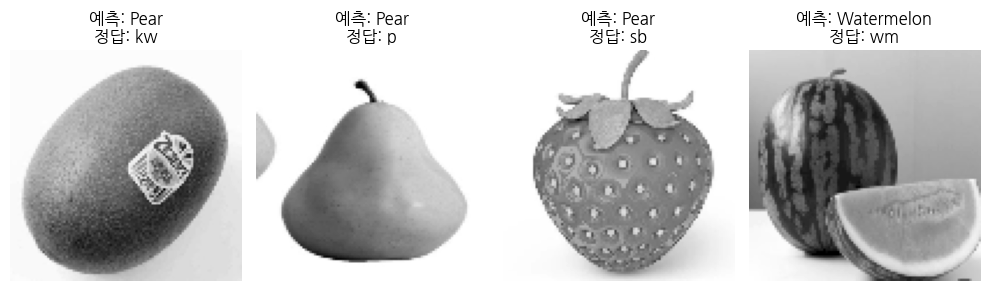

In [59]:
fig, axes = plt.subplots( 1, len(new_files), figsize=(10, 4))
axes = np.atleast_1d(axes)

for ax, data, pred, label in zip( axes, new_data, pre_y, new_label):
    ax.imshow( data.reshape(100, 100), cmap="gray")
    ax.set_title( f"예측: {pred}\n정답: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()